# Notebook 5: Build Region Adjacency Graph

## Purpose

This notebook constructs a topological graph from the WGS84 regional aggregates generated in Notebook 4.

The resulting graph represents geometric adjacency between regions and forms the foundation for future transport network encoding. At this stage, connectivity is based solely on region boundaries and does not yet account for existing infrastructure.

Road, rail, marine, and pipeline networks will be incorporated in subsequent notebooks as modal layers that modify the base graph.

## Inputs

From Notebook 4:

- `canada_basemap_1deg_centroid.gpkg`

## Outputs

- `region_adjacency.csv`
- `region_adjacency.gpkg`
- `region_nodes.csv`
- `region_nodes.gpkg`

## Methodology

1. Load WGS84 regional polygons.
2. Assign stable region identifiers.
3. Compute polygon centroids.
4. Determine neighboring regions using rook adjacency (shared boundaries).
5. Calculate centroid-to-centroid distances.
6. Export node and edge tables for downstream geospatial and TEMOA applications.

## Notes

The adjacency graph represents potential spatial connectivity only.

Infrastructure availability and transport technologies are treated separately and will be introduced in later notebooks.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from geopy.distance import distance
import matplotlib.pyplot as plt

In [2]:
# =============================================================================
# Project directories
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILES = PROJECT_ROOT / "data_files"

RAW_DATA = DATA_FILES / "raw"
PROCESSED_DATA = DATA_FILES / "processed"

PROCESSED_BASEMAP = PROCESSED_DATA / "basemaps"
PROCESSED_GRAPH = PROCESSED_DATA / "graph"
PROCESSED_NRN = PROCESSED_DATA / "nrn"

# Create output directory
PROCESSED_GRAPH.mkdir(parents=True, exist_ok=True)

In [3]:
# =============================================================================
# Discover available basemap files
# =============================================================================

basemap_files = sorted(
    PROCESSED_BASEMAP.glob(
        "canada_basemap_*.gpkg"
    )
)

if not basemap_files:
    raise FileNotFoundError(
        f"No basemap files found in {PROCESSED_BASEMAP}"
    )

print(
    f"Found {len(basemap_files):,} basemap files:"
)

for basemap_file in basemap_files:
    print(f"  • {basemap_file.name}")


Found 12 basemap files:
  • canada_basemap_0.5deg_centroid.gpkg
  • canada_basemap_0.5deg_intersects.gpkg
  • canada_basemap_1deg_centroid.gpkg
  • canada_basemap_1deg_intersects.gpkg
  • canada_basemap_2deg_centroid.gpkg
  • canada_basemap_2deg_intersects.gpkg
  • canada_basemap_3deg_centroid.gpkg
  • canada_basemap_3deg_intersects.gpkg
  • canada_basemap_4deg_centroid.gpkg
  • canada_basemap_4deg_intersects.gpkg
  • canada_basemap_5deg_centroid.gpkg
  • canada_basemap_5deg_intersects.gpkg


In [4]:
# =============================================================================
# Load first basemap for notebook inspection
# =============================================================================

BASEMAP_PATH = basemap_files[0]

print(
    f"\nLoading inspection basemap:\n"
    f"{BASEMAP_PATH.name}"
)

regions = gpd.read_file(
    BASEMAP_PATH
)

print(f"Loaded {len(regions):,} regions")
print(f"CRS: {regions.crs}")

regions.head()


Loading inspection basemap:
canada_basemap_0.5deg_centroid.gpkg
Loaded 6,749 regions
CRS: EPSG:4326


,lon_min,lon_max,lat_min,lat_max,lon,lat,region,site_id,resolution_deg,keep_method,geometry
0,-83.0,-82.5,42.0,42.5,-82.75,42.25,R0,R0,0.5,centroid,"POLYGON ((-82.5 42, -82.5 42.5, -83 42.5, -83 ..."
1,-82.5,-82.0,42.0,42.5,-82.25,42.25,R1,R1,0.5,centroid,"POLYGON ((-82 42, -82 42.5, -82.5 42.5, -82.5 ..."
2,-82.5,-82.0,42.5,43.0,-82.25,42.75,R2,R2,0.5,centroid,"POLYGON ((-82 42.5, -82 43, -82.5 43, -82.5 42..."
3,-82.0,-81.5,42.5,43.0,-81.75,42.75,R3,R3,0.5,centroid,"POLYGON ((-81.5 42.5, -81.5 43, -82 43, -82 42..."
4,-81.5,-81.0,42.5,43.0,-81.25,42.75,R4,R4,0.5,centroid,"POLYGON ((-81 42.5, -81 43, -81.5 43, -81.5 42..."


In [5]:
# =============================================================================
# Build region adjacency graph for one basemap
# =============================================================================

def build_region_adjacency(
    basemap_path: Path,
    coord_precision: int = 6,
) -> tuple[gpd.GeoDataFrame, pd.DataFrame]:

    print("\n" + "=" * 80)
    print(f"Processing basemap: {basemap_path.name}")
    print("=" * 80)

    regions = gpd.read_file(
        basemap_path
    )

    print(f"Loaded regions: {len(regions):,}")
    print(f"CRS: {regions.crs}")

    required_columns = [
        "region",
        "site_id",
        "lon",
        "lat",
        "resolution_deg",
        "keep_method",
        "geometry",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in regions.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{basemap_path.name} missing columns: {missing_columns}"
        )

    assert regions["region"].is_unique
    assert regions["site_id"].is_unique
    assert (
        regions[["lon", "lat"]]
        .drop_duplicates()
        .shape[0]
        == len(regions)
    )

    resolution_values = regions["resolution_deg"].unique()
    keep_method_values = regions["keep_method"].unique()

    assert len(resolution_values) == 1
    assert len(keep_method_values) == 1

    resolution = float(resolution_values[0])
    keep_method = str(keep_method_values[0])

    print(f"Resolution: {resolution:g}°")
    print(f"Keep method: {keep_method}")

    # -------------------------------------------------------------------------
    # Coordinate lookup
    # -------------------------------------------------------------------------

    regions["lon_key"] = regions["lon"].round(coord_precision)
    regions["lat_key"] = regions["lat"].round(coord_precision)

    coord_to_region = {
        (row.lon_key, row.lat_key): row.region
        for row in regions.itertuples(index=False)
    }

    # -------------------------------------------------------------------------
    # Assign rook neighbours
    # -------------------------------------------------------------------------

    regions["up_id"] = [
        coord_to_region.get(
            (
                round(row.lon_key, coord_precision),
                round(row.lat_key + resolution, coord_precision),
            ),
            "R-999",
        )
        for row in regions.itertuples(index=False)
    ]

    regions["down_id"] = [
        coord_to_region.get(
            (
                round(row.lon_key, coord_precision),
                round(row.lat_key - resolution, coord_precision),
            ),
            "R-999",
        )
        for row in regions.itertuples(index=False)
    ]

    regions["right_id"] = [
        coord_to_region.get(
            (
                round(row.lon_key + resolution, coord_precision),
                round(row.lat_key, coord_precision),
            ),
            "R-999",
        )
        for row in regions.itertuples(index=False)
    ]

    regions["left_id"] = [
        coord_to_region.get(
            (
                round(row.lon_key - resolution, coord_precision),
                round(row.lat_key, coord_precision),
            ),
            "R-999",
        )
        for row in regions.itertuples(index=False)
    ]

    # -------------------------------------------------------------------------
    # Graph diagnostics
    # -------------------------------------------------------------------------

    neighbor_cols = [
        "up_id",
        "down_id",
        "right_id",
        "left_id",
    ]

    regions["n_neighbors"] = sum(
        (regions[col] != "R-999").astype(int)
        for col in neighbor_cols
    )

    print("Neighbour count distribution:")
    print(
        regions["n_neighbors"]
        .value_counts()
        .sort_index()
    )

    print(
        f"Average neighbours: "
        f"{regions['n_neighbors'].mean():.2f}"
    )

    print(
        f"Isolated regions: "
        f"{(regions['n_neighbors'] == 0).sum():,}"
    )

    # -------------------------------------------------------------------------
    # Distance calculation
    # -------------------------------------------------------------------------

    region_lookup = (
        regions
        .set_index("region")[["lat", "lon"]]
        .to_dict("index")
    )

    directions = [
        "up",
        "down",
        "right",
        "left",
    ]

    for direction in directions:

        distance_col = f"{direction}_distance"
        neighbor_col = f"{direction}_id"

        regions[distance_col] = np.nan

        for row in regions.itertuples():

            neighbor = getattr(row, neighbor_col)

            if neighbor != "R-999":

                coord1 = (
                    row.lat,
                    row.lon,
                )

                coord2 = (
                    region_lookup[neighbor]["lat"],
                    region_lookup[neighbor]["lon"],
                )

                regions.at[
                    row.Index,
                    distance_col,
                ] = distance(
                    coord1,
                    coord2,
                ).km

    # -------------------------------------------------------------------------
    # Build directed edge table
    # -------------------------------------------------------------------------

    neighbor_map = {
        "up_id": "up",
        "down_id": "down",
        "right_id": "right",
        "left_id": "left",
    }

    edge_rows = []

    for row in regions.itertuples(index=False):

        for neighbor_col, direction in neighbor_map.items():

            region_to = getattr(row, neighbor_col)

            if region_to != "R-999":

                distance_col = f"{direction}_distance"

                edge_rows.append(
                    {
                        "edge_region": f"{row.region}-{region_to}",
                        "region_from": row.region,
                        "region_to": region_to,
                        "direction": direction,
                        "lon_from": row.lon,
                        "lat_from": row.lat,
                        "lon_to": region_lookup[region_to]["lon"],
                        "lat_to": region_lookup[region_to]["lat"],
                        "distance_km": getattr(row, distance_col),
                        "resolution_deg": row.resolution_deg,
                        "keep_method": row.keep_method,
                    }
                )

    adjacency_edges = pd.DataFrame(
        edge_rows
    )

    print(
        f"Directed adjacency edges: "
        f"{len(adjacency_edges):,}"
    )

    regions = regions.drop(
        columns=[
            "lon_key",
            "lat_key",
        ],
        errors="ignore",
    )

    return regions, adjacency_edges

In [6]:
# =============================================================================
# Build and export adjacency graphs for all discovered basemaps
# =============================================================================

graph_summary_rows = []

for basemap_path in basemap_files:

    regions_graph, adjacency_edges = build_region_adjacency(
        basemap_path=basemap_path,
    )

    output_prefix = basemap_path.stem

    output_node_gpkg_path = (
        PROCESSED_GRAPH
        / f"{output_prefix}_graph_nodes.gpkg"
    )

    output_node_csv_path = (
        PROCESSED_GRAPH
        / f"{output_prefix}_graph_nodes.csv"
    )

    output_edge_csv_path = (
        PROCESSED_GRAPH
        / f"{output_prefix}_graph_edges.csv"
    )

    regions_graph.to_file(
        output_node_gpkg_path,
        driver="GPKG",
    )

    regions_graph.drop(
        columns="geometry",
    ).to_csv(
        output_node_csv_path,
        index=False,
    )

    adjacency_edges.to_csv(
        output_edge_csv_path,
        index=False,
    )

    graph_summary_rows.append(
        {
            "basemap_file": basemap_path.name,
            "resolution_deg": regions_graph["resolution_deg"].iloc[0],
            "keep_method": regions_graph["keep_method"].iloc[0],
            "nodes": len(regions_graph),
            "directed_edges": len(adjacency_edges),
            "average_neighbors": regions_graph["n_neighbors"].mean(),
            "isolated_nodes": int(
                (regions_graph["n_neighbors"] == 0).sum()
            ),
            "node_gpkg": output_node_gpkg_path.name,
            "node_csv": output_node_csv_path.name,
            "edge_csv": output_edge_csv_path.name,
        }
    )

    print(f"Exported: {output_node_gpkg_path.name}")
    print(f"Exported: {output_node_csv_path.name}")
    print(f"Exported: {output_edge_csv_path.name}")

graph_summary = pd.DataFrame(
    graph_summary_rows
)

graph_summary_path = (
    PROCESSED_GRAPH
    / "region_adjacency_graph_summary.csv"
)

graph_summary.to_csv(
    graph_summary_path,
    index=False,
)

print("\nAll graph builds complete.")
print(f"Exported summary: {graph_summary_path.name}")

graph_summary


Processing basemap: canada_basemap_0.5deg_centroid.gpkg
Loaded regions: 6,749
CRS: EPSG:4326
Resolution: 0.5°
Keep method: centroid
Neighbour count distribution:
n_neighbors
0      20
1     140
2     453
3     920
4    5216
Name: count, dtype: int64
Average neighbours: 3.66
Isolated regions: 20
Directed adjacency edges: 24,670
Exported: canada_basemap_0.5deg_centroid_graph_nodes.gpkg
Exported: canada_basemap_0.5deg_centroid_graph_nodes.csv
Exported: canada_basemap_0.5deg_centroid_graph_edges.csv

Processing basemap: canada_basemap_0.5deg_intersects.gpkg
Loaded regions: 8,257
CRS: EPSG:4326
Resolution: 0.5°
Keep method: intersects
Neighbour count distribution:
n_neighbors
1      29
2     354
3     833
4    7041
Name: count, dtype: int64
Average neighbours: 3.80
Isolated regions: 0
Directed adjacency edges: 31,400
Exported: canada_basemap_0.5deg_intersects_graph_nodes.gpkg
Exported: canada_basemap_0.5deg_intersects_graph_nodes.csv
Exported: canada_basemap_0.5deg_intersects_graph_edges.c

,basemap_file,resolution_deg,keep_method,nodes,directed_edges,average_neighbors,isolated_nodes,node_gpkg,node_csv,edge_csv
0,canada_basemap_0.5deg_centroid.gpkg,0.5,centroid,6749,24670,3.655356,20,canada_basemap_0.5deg_centroid_graph_nodes.gpkg,canada_basemap_0.5deg_centroid_graph_nodes.csv,canada_basemap_0.5deg_centroid_graph_edges.csv
1,canada_basemap_0.5deg_intersects.gpkg,0.5,intersects,8257,31400,3.802834,0,canada_basemap_0.5deg_intersects_graph_nodes.gpkg,canada_basemap_0.5deg_intersects_graph_nodes.csv,canada_basemap_0.5deg_intersects_graph_edges.csv
2,canada_basemap_1deg_centroid.gpkg,1.0,centroid,1692,5886,3.478723,9,canada_basemap_1deg_centroid_graph_nodes.gpkg,canada_basemap_1deg_centroid_graph_nodes.csv,canada_basemap_1deg_centroid_graph_edges.csv
3,canada_basemap_1deg_intersects.gpkg,1.0,intersects,2276,8580,3.769772,0,canada_basemap_1deg_intersects_graph_nodes.gpkg,canada_basemap_1deg_intersects_graph_nodes.csv,canada_basemap_1deg_intersects_graph_edges.csv
4,canada_basemap_2deg_centroid.gpkg,2.0,centroid,415,1320,3.180723,8,canada_basemap_2deg_centroid_graph_nodes.gpkg,canada_basemap_2deg_centroid_graph_nodes.csv,canada_basemap_2deg_centroid_graph_edges.csv
5,canada_basemap_2deg_intersects.gpkg,2.0,intersects,633,2354,3.718799,0,canada_basemap_2deg_intersects_graph_nodes.gpkg,canada_basemap_2deg_intersects_graph_nodes.csv,canada_basemap_2deg_intersects_graph_edges.csv
6,canada_basemap_3deg_centroid.gpkg,3.0,centroid,194,594,3.061856,0,canada_basemap_3deg_centroid_graph_nodes.gpkg,canada_basemap_3deg_centroid_graph_nodes.csv,canada_basemap_3deg_centroid_graph_edges.csv
7,canada_basemap_3deg_intersects.gpkg,3.0,intersects,296,1070,3.614865,0,canada_basemap_3deg_intersects_graph_nodes.gpkg,canada_basemap_3deg_intersects_graph_nodes.csv,canada_basemap_3deg_intersects_graph_edges.csv
8,canada_basemap_4deg_centroid.gpkg,4.0,centroid,107,308,2.878505,1,canada_basemap_4deg_centroid_graph_nodes.gpkg,canada_basemap_4deg_centroid_graph_nodes.csv,canada_basemap_4deg_centroid_graph_edges.csv
9,canada_basemap_4deg_intersects.gpkg,4.0,intersects,184,654,3.554348,0,canada_basemap_4deg_intersects_graph_nodes.gpkg,canada_basemap_4deg_intersects_graph_nodes.csv,canada_basemap_4deg_intersects_graph_edges.csv


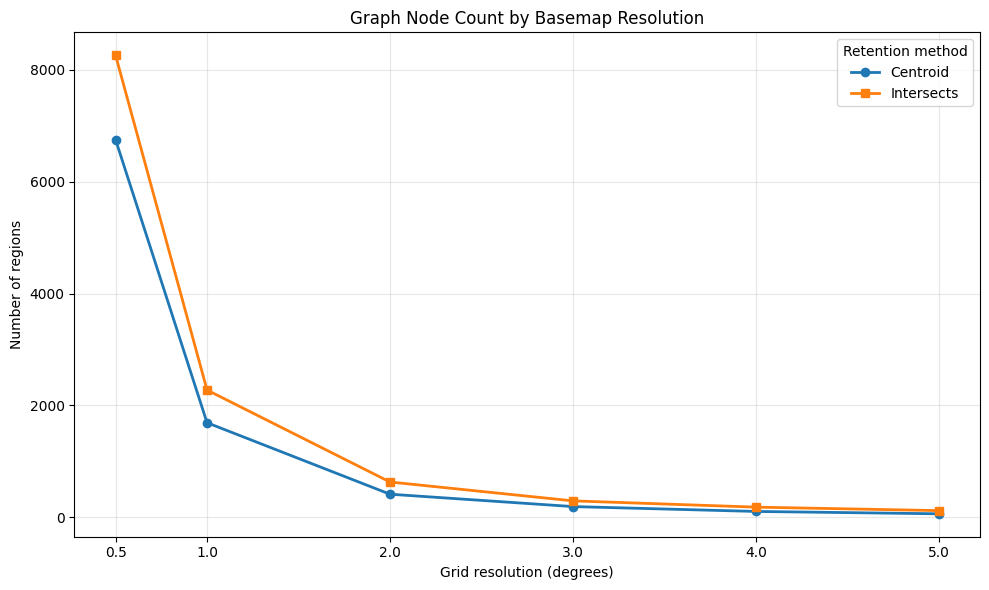

In [17]:
# =============================================================================
# Plot graph node count by basemap resolution
# =============================================================================

centroid = (
    graph_summary[
        graph_summary["keep_method"] == "centroid"
    ]
    .sort_values("resolution_deg")
)

intersects = (
    graph_summary[
        graph_summary["keep_method"] == "intersects"
    ]
    .sort_values("resolution_deg")
)

fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    centroid["resolution_deg"],
    centroid["nodes"],
    marker="o",
    linewidth=2,
    label="Centroid",
)

ax.plot(
    intersects["resolution_deg"],
    intersects["nodes"],
    marker="s",
    linewidth=2,
    label="Intersects",
)

ax.set_title(
    "Graph Node Count by Basemap Resolution"
)

ax.set_xlabel(
    "Grid resolution (degrees)"
)

ax.set_ylabel(
    "Number of regions"
)

ax.set_xticks(
    sorted(
        graph_summary["resolution_deg"].unique()
    )
)

ax.grid(
    alpha=0.3,
)

ax.legend(
    title="Retention method"
)

plt.tight_layout()

plt.show()

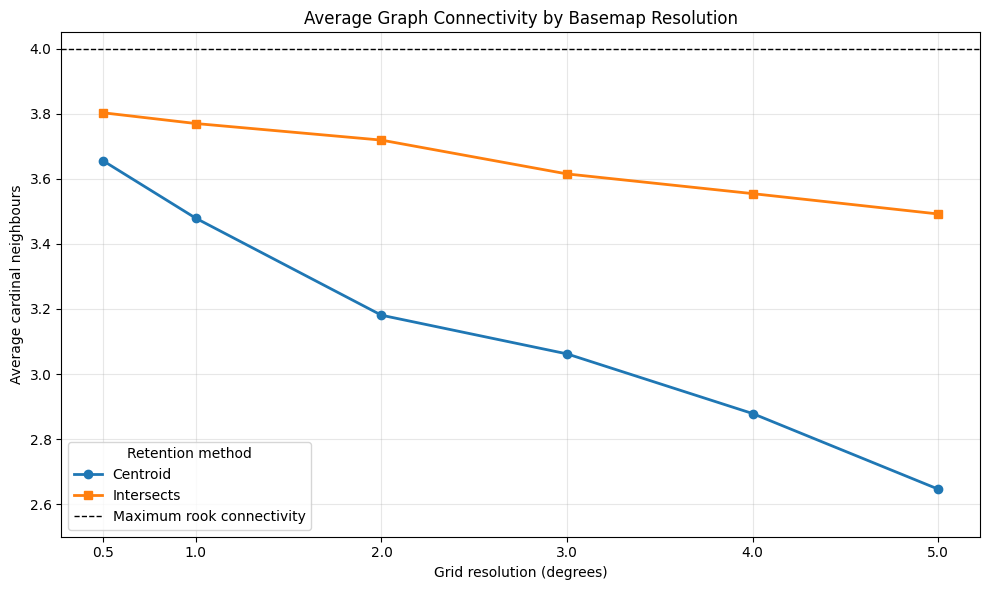

In [19]:
# =============================================================================
# Plot average graph connectivity by basemap resolution
# =============================================================================

centroid = (
    graph_summary[
        graph_summary["keep_method"] == "centroid"
    ]
    .sort_values("resolution_deg")
)

intersects = (
    graph_summary[
        graph_summary["keep_method"] == "intersects"
    ]
    .sort_values("resolution_deg")
)

fig, ax = plt.subplots(
    figsize=(10, 6),
)

ax.plot(
    centroid["resolution_deg"],
    centroid["average_neighbors"],
    marker="o",
    linewidth=2,
    label="Centroid",
)

ax.plot(
    intersects["resolution_deg"],
    intersects["average_neighbors"],
    marker="s",
    linewidth=2,
    label="Intersects",
)

ax.axhline(
    y=4,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Maximum rook connectivity",
)

ax.set_title(
    "Average Graph Connectivity by Basemap Resolution"
)

ax.set_xlabel(
    "Grid resolution (degrees)"
)

ax.set_ylabel(
    "Average cardinal neighbours"
)

ax.set_xticks(
    sorted(
        graph_summary["resolution_deg"].unique()
    )
)

ax.set_ylim(
    2.5,
    4.05,
)

ax.grid(
    alpha=0.3,
)

ax.legend(
    title="Retention method"
)

plt.tight_layout()

plt.show()

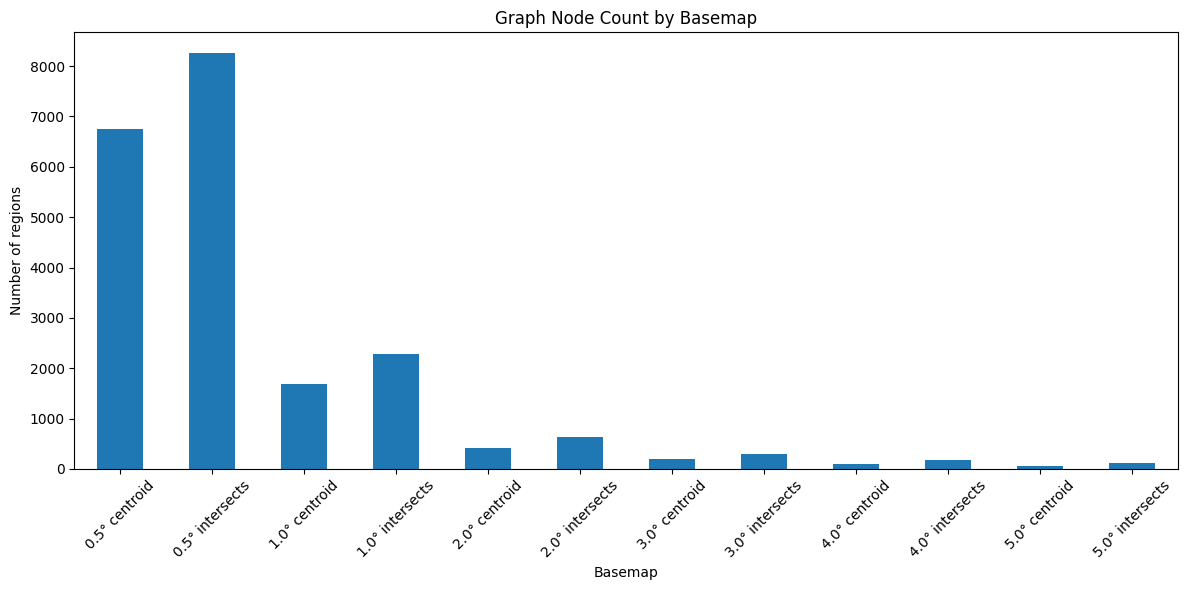

In [14]:
# =============================================================================
# Plot graph summary diagnostics
# =============================================================================

graph_summary_plot = graph_summary.copy()

graph_summary_plot["scenario"] = (
    graph_summary_plot["resolution_deg"].astype(str)
    + "° "
    + graph_summary_plot["keep_method"].astype(str)
)

fig, ax = plt.subplots(
    figsize=(12, 6),
)

graph_summary_plot.sort_values(
    by=[
        "resolution_deg",
        "keep_method",
    ]
).plot(
    x="scenario",
    y="nodes",
    kind="bar",
    ax=ax,
    legend=False,
)

ax.set_title("Graph Node Count by Basemap")
ax.set_xlabel("Basemap")
ax.set_ylabel("Number of regions")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

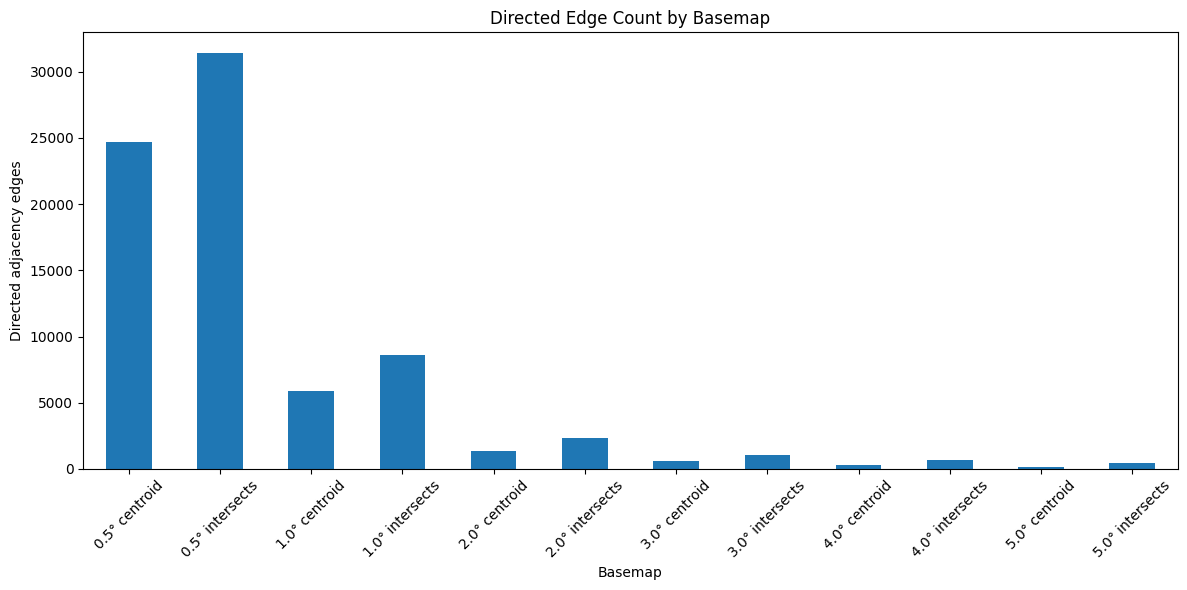

In [8]:
# Plot directed edge counts.

fig, ax = plt.subplots(
    figsize=(12, 6),
)

graph_summary_plot.sort_values(
    by=[
        "resolution_deg",
        "keep_method",
    ]
).plot(
    x="scenario",
    y="directed_edges",
    kind="bar",
    ax=ax,
    legend=False,
)

ax.set_title("Directed Edge Count by Basemap")
ax.set_xlabel("Basemap")
ax.set_ylabel("Directed adjacency edges")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

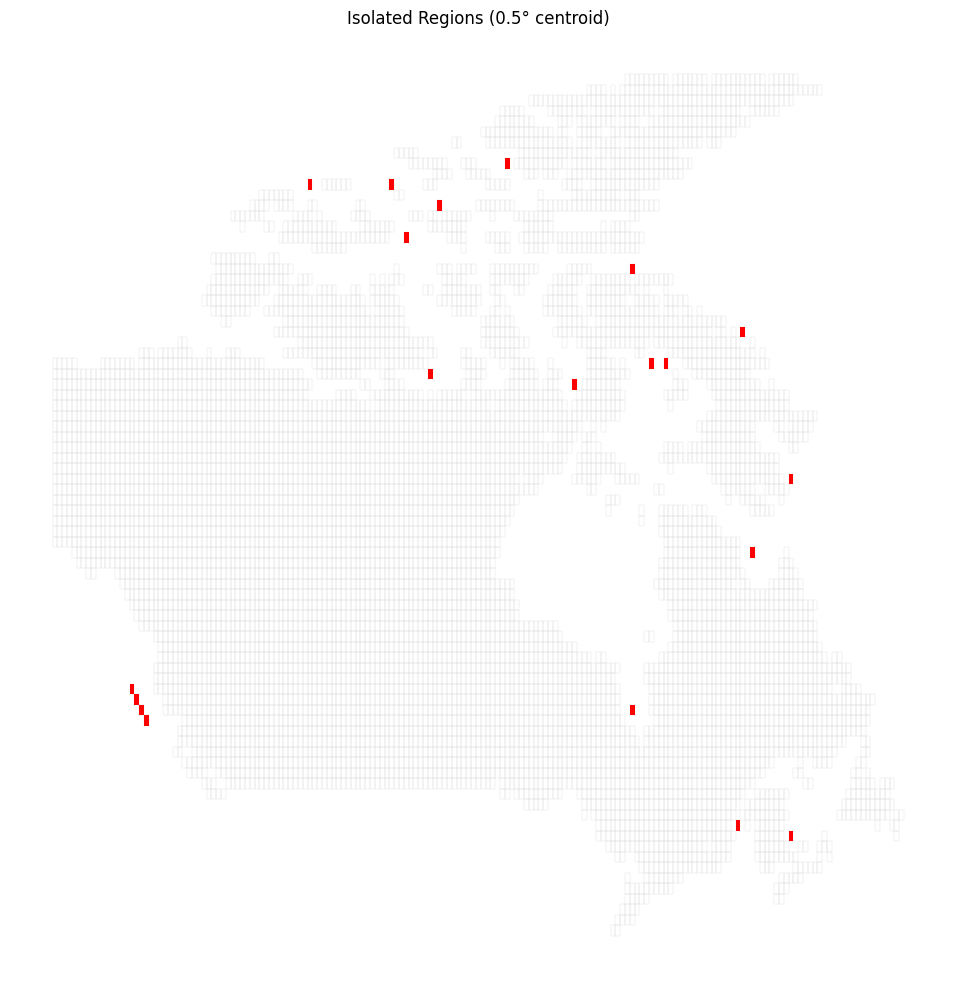

In [9]:
# =============================================================================
# Plot selected graph nodes and isolated regions
# =============================================================================

selected_graph_path = (
    PROCESSED_GRAPH
    / graph_summary["node_gpkg"].iloc[0]
)

regions_check = gpd.read_file(
    selected_graph_path
)

resolution = regions_check["resolution_deg"].iloc[0]
keep_method = regions_check["keep_method"].iloc[0]

isolated_regions = regions_check.loc[
    regions_check["n_neighbors"] == 0
]

fig, ax = plt.subplots(
    figsize=(12, 10),
)

regions_check.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.2,
)

if not isolated_regions.empty:
    isolated_regions.plot(
        ax=ax,
        color="red",
    )

ax.set_title(
    f"Isolated Regions "
    f"({resolution:g}° {keep_method})"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()